# Spotify Streaming Audit - Modelos ML
**Equipo 3** | TripleTen Data Science Bootcamp

> Archivo separado del EDA. Requiere `spotify_eda_clean.csv` o
> `spotify-2000-joined-clean.csv` disponible en el entorno.

---

## Indice
1. Configuracion e importacion de datos
2. Modelo 1 - Regresion Lineal
   - 2.1 Preparacion de datos
   - 2.2 Modelo base: loudness_db, energy, acousticness
   - 2.3 Modelo extendido: + winner
   - 2.4 Comparacion de modelos
   - 2.5 Interpretacion de coeficientes
   - 2.6 Visualizacion de resultados
3. Modelo 2 - Clustering K-Means
   - 3.1 Normalizacion de variables
   - 3.2 Metodo del codo
   - 3.3 Entrenamiento del modelo final
   - 3.4 Perfil de cada cluster
   - 3.5 Distribucion de ganadores Grammy por cluster
   - 3.6 Visualizacion 2D de clusters
4. Conclusiones y criterios para el servicio premium

---
## 1. Configuracion e importacion de datos

In [ ]:
# !pip install -q scikit-learn joblib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
import joblib

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

import warnings
warnings.filterwarnings('ignore')

print('Entorno configurado.')

Entorno configurado.


In [2]:
try:
    # df = pd.read_csv('spotify_eda_clean.csv')
    df = pd.read_csv(r'C:\Users\ELITEBOOK\Documents\Hackathon_3T\spotify-streaming-audit-tripleten-g3\data\processed\spotify-2000-joined-clean.csv')
    print('Cargado desde spotify_eda_clean.csv')
except FileNotFoundError:
    df = pd.read_csv('spotify-2000-joined-clean.csv')
    df['decade_label'] = df['decade'].astype(str) + 's'
    print('Cargado desde spotify-2000-joined-clean.csv')

# Convertir winner a entero (True=1, False=0) para usarlo en modelos
df['winner_int'] = df['winner'].astype(int)

print(f'Dataset: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Ganadores Grammy: {df["winner_int"].sum()} ({df["winner_int"].mean()*100:.1f}%)')
df[['loudness_db', 'energy', 'acousticness', 'winner_int', 'popularity']].describe().round(2)

Cargado desde spotify_eda_clean.csv
Dataset: 1,994 filas x 18 columnas
Ganadores Grammy: 112 (5.6%)


,loudness_db,energy,acousticness,winner_int,popularity
count,1994.00,1994.00,1994.00,1994.00,1994.00
mean,-9.01,59.68,28.86,0.06,59.53
std,3.65,22.15,29.01,0.23,14.35
min,-27.00,3.00,0.00,0.00,11.00
25%,-11.00,42.00,3.00,0.00,49.25
50%,-8.00,61.00,18.00,0.00,62.00
75%,-6.00,78.00,50.00,0.00,71.00
max,-2.00,100.00,99.00,1.00,100.00


In [3]:
df

,title,artist,genre,year,bpm,energy,danceability,loudness_db,liveness,valence,duration,acousticness,speechiness,popularity,decade,popularity_segment,winner,winner_int
0,sunrise,norah_jones,adult_standards,2004,157,30,53,-14,11,68,201,94,3,71,2000,media-alta,True,1
1,the_pretender,foo_fighters,alternative_metal,2007,173,96,43,-4,3,37,269,0,4,76,2000,alta,True,1
2,without_me,eminem,detroit_hip_hop,2002,112,67,91,-3,24,66,290,0,7,82,2000,alta,True,1
3,uninvited,alanis_morissette,alternative_rock,2005,127,54,38,-5,9,19,276,2,3,57,2000,media-baja,True,1
4,cry_me_a_river,justin_timberlake,dance_pop,2002,74,65,62,-7,10,56,288,57,18,74,2000,alta,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,heartbreak_hotel,elvis_presley,adult_standards,1958,94,21,70,-12,11,72,128,84,7,63,1950,media-alta,False,0
1990,hound_dog,elvis_presley,adult_standards,1958,175,76,36,-8,76,95,136,73,6,69,1950,media-alta,False,0
1991,johnny_b._goode,chuck_berry,blues_rock,1959,168,80,53,-9,31,97,162,74,7,74,1950,alta,False,0
1992,take_five,the_dave_brubeck_quartet,bebop,1959,174,26,45,-13,7,60,324,54,4,65,1950,media-alta,False,0


In [4]:
# 3. Detección Matemática de Outliers usando el Método IQR (Rango Intercuartílico)
print("\n=== 3. DETECCIÓN DE OUTLIERS MEDIANTE IQR (Factor: 1.5) ===")

# Identificamos las columnas numéricas
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

resumen_outliers = {}

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Límites teóricos de Tukey
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Conteo de anomalías fuera de las fronteras
    outliers_inf = (df[col] < limite_inferior).sum()
    outliers_sup = (df[col] > limite_superior).sum()
    total_outliers = outliers_inf + outliers_sup
    pct_outliers = (total_outliers / len(df)) * 100
    
    resumen_outliers[col] = {
        'Límite Inferior': round(limite_inferior, 2),
        'Límite Superior': round(limite_superior, 2),
        'Total Outliers': total_outliers,
        'Porcentaje (%)': round(pct_outliers, 2)
    }

df_reporte_outliers = pd.DataFrame(resumen_outliers).T
print(df_reporte_outliers)
print("-" * 60)


=== 3. DETECCIÓN DE OUTLIERS MEDIANTE IQR (Factor: 1.5) ===
              Límite Inferior  Límite Superior  Total Outliers  Porcentaje (%)
year                  1937.00          2049.00             0.0            0.00
bpm                     43.50           191.50            17.0            0.85
energy                 -12.00           132.00             0.0            0.00
danceability            11.50            95.50             3.0            0.15
loudness_db            -18.50             1.50            31.0            1.55
liveness               -12.00            44.00           138.0            6.92
valence                -32.12           130.88             0.0            0.00
duration                96.50           404.50           106.0            5.32
acousticness           -67.50           120.50             0.0            0.00
speechiness              0.00             8.00           174.0            8.73
popularity              16.62           103.62             9.0        

---
## 2. Modelo 1 - Regresion Lineal

Comparamos dos versiones del modelo para medir el impacto real de `winner`:

- **Modelo base:** `loudness_db`, `energy`, `acousticness`
- **Modelo extendido:** los mismos 3 + `winner`

### 2.1 Preparacion de datos

In [5]:
FEATURES_BASE     = ['loudness_db', 'energy', 'acousticness']
FEATURES_EXT      = ['loudness_db', 'energy', 'acousticness', 'winner_int']
TARGET            = 'popularity'

# Mismo split para ambos modelos — garantiza comparacion justa
X_base = df[FEATURES_BASE]
X_ext  = df[FEATURES_EXT]
y      = df[TARGET]

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)
X_ext_train, X_ext_test, _, _ = train_test_split(
    X_ext, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_base_train.shape[0]:,} canciones')
print(f'Prueba:        {X_base_test.shape[0]:,} canciones')
print(f'Ganadores Grammy en prueba: {X_ext_test["winner_int"].sum()} ({X_ext_test["winner_int"].mean()*100:.1f}%)')

Entrenamiento: 1,595 canciones
Prueba:        399 canciones
Ganadores Grammy en prueba: 21 (5.3%)


### 2.2 Modelo base: loudness_db, energy, acousticness

In [6]:
modelo_base = LinearRegression()
modelo_base.fit(X_base_train, y_train)
y_pred_base = modelo_base.predict(X_base_test)

r2_base   = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)

print('Modelo base (3 variables):')
print(f'  R2   = {r2_base:.4f}')
print(f'  RMSE = {rmse_base:.2f}')
print(f'  MAE  = {mae_base:.2f}')

Modelo base (3 variables):
  R2   = 0.0216
  RMSE = 13.54
  MAE  = 11.30


### 2.3 Modelo extendido: + winner

In [7]:
modelo_ext = LinearRegression()
modelo_ext.fit(X_ext_train, y_train)
y_pred_ext = modelo_ext.predict(X_ext_test)

r2_ext   = r2_score(y_test, y_pred_ext)
rmse_ext = np.sqrt(mean_squared_error(y_test, y_pred_ext))
mae_ext  = mean_absolute_error(y_test, y_pred_ext)

print('Modelo extendido (3 variables + winner):')
print(f'  R2   = {r2_ext:.4f}')
print(f'  RMSE = {rmse_ext:.2f}')
print(f'  MAE  = {mae_ext:.2f}')

Modelo extendido (3 variables + winner):
  R2   = 0.0398
  RMSE = 13.42
  MAE  = 11.10


### 2.4 Comparacion de modelos

In [8]:
delta_r2   = r2_ext - r2_base
delta_rmse = rmse_base - rmse_ext
delta_mae  = mae_base - mae_ext

print('=' * 55)
print('  COMPARACION DE MODELOS')
print('=' * 55)
print(f'  {"Metrica":<10} {"Base":>10} {"+ winner":>10} {"Mejora":>10}')
print(f'  {"-"*46}')
print(f'  {"R2":<10} {r2_base:>10.4f} {r2_ext:>10.4f} {delta_r2:>+10.4f}')
print(f'  {"RMSE":<10} {rmse_base:>10.2f} {rmse_ext:>10.2f} {-delta_rmse:>+10.2f}')
print(f'  {"MAE":<10} {mae_base:>10.2f} {mae_ext:>10.2f} {-delta_mae:>+10.2f}')
print('=' * 55)

if abs(delta_r2) < 0.005:
    print('Conclusion: winner NO mejora significativamente el modelo.')
    print('El perfil sonoro (loudness, energy, acousticness) es el predictor principal.')
    print('winner es un factor externo al audio que no cambia como suena la cancion.')
elif delta_r2 > 0:
    print(f'Conclusion: winner mejora el R2 en {delta_r2:.4f} puntos.')
    print('Tiene poder predictivo adicional — vale la pena incluirla en el modelo final.')
else:
    print('Conclusion: winner no aporta poder predictivo adicional.')

# Definir modelo final para las siguientes secciones
if delta_r2 >= 0.005:
    modelo_reg  = modelo_ext
    FEATURES_FIN = FEATURES_EXT
    y_pred      = y_pred_ext
    r2, rmse, mae = r2_ext, rmse_ext, mae_ext
    print('Modelo seleccionado: extendido (con winner)')
else:
    modelo_reg  = modelo_base
    FEATURES_FIN = FEATURES_BASE
    y_pred      = y_pred_base
    r2, rmse, mae = r2_base, rmse_base, mae_base
    print('Modelo seleccionado: base (sin winner)')

  COMPARACION DE MODELOS
  Metrica          Base   + winner     Mejora
  ----------------------------------------------
  R2             0.0216     0.0398    +0.0182
  RMSE            13.54      13.42      -0.13
  MAE             11.30      11.10      -0.20
Conclusion: winner mejora el R2 en 0.0182 puntos.
Tiene poder predictivo adicional — vale la pena incluirla en el modelo final.
Modelo seleccionado: extendido (con winner)


### 2.5 Interpretacion de coeficientes

In [9]:
coeficientes = pd.DataFrame({
    'variable'   : FEATURES_EXT,
    'base'       : list(modelo_base.coef_) + [0],
    'extendido'  : modelo_ext.coef_,
}).set_index('variable')

print(f'Intercepto base:     {modelo_base.intercept_:.2f}')
print(f'Intercepto extendido: {modelo_ext.intercept_:.2f}')
print()
print('Coeficientes por modelo:')
print(coeficientes.round(4).to_string())
print()
print('Interpretacion (modelo extendido):')
for feat, coef in zip(FEATURES_EXT, modelo_ext.coef_):
    direccion = 'sube' if coef > 0 else 'baja'
    print(f'  {feat:<15} -> popularity {direccion} {abs(coef):.2f} pts por cada unidad')

Intercepto base:     71.76
Intercepto extendido: 69.00

Coeficientes por modelo:
                base  extendido
variable                       
loudness_db   0.8071     0.6815
energy       -0.0709    -0.0550
acousticness -0.0357    -0.0320
winner_int    0.0000    10.1941

Interpretacion (modelo extendido):
  loudness_db     -> popularity sube 0.68 pts por cada unidad
  energy          -> popularity baja 0.05 pts por cada unidad
  acousticness    -> popularity baja 0.03 pts por cada unidad
  winner_int      -> popularity sube 10.19 pts por cada unidad


### 2.6 Visualizacion de resultados

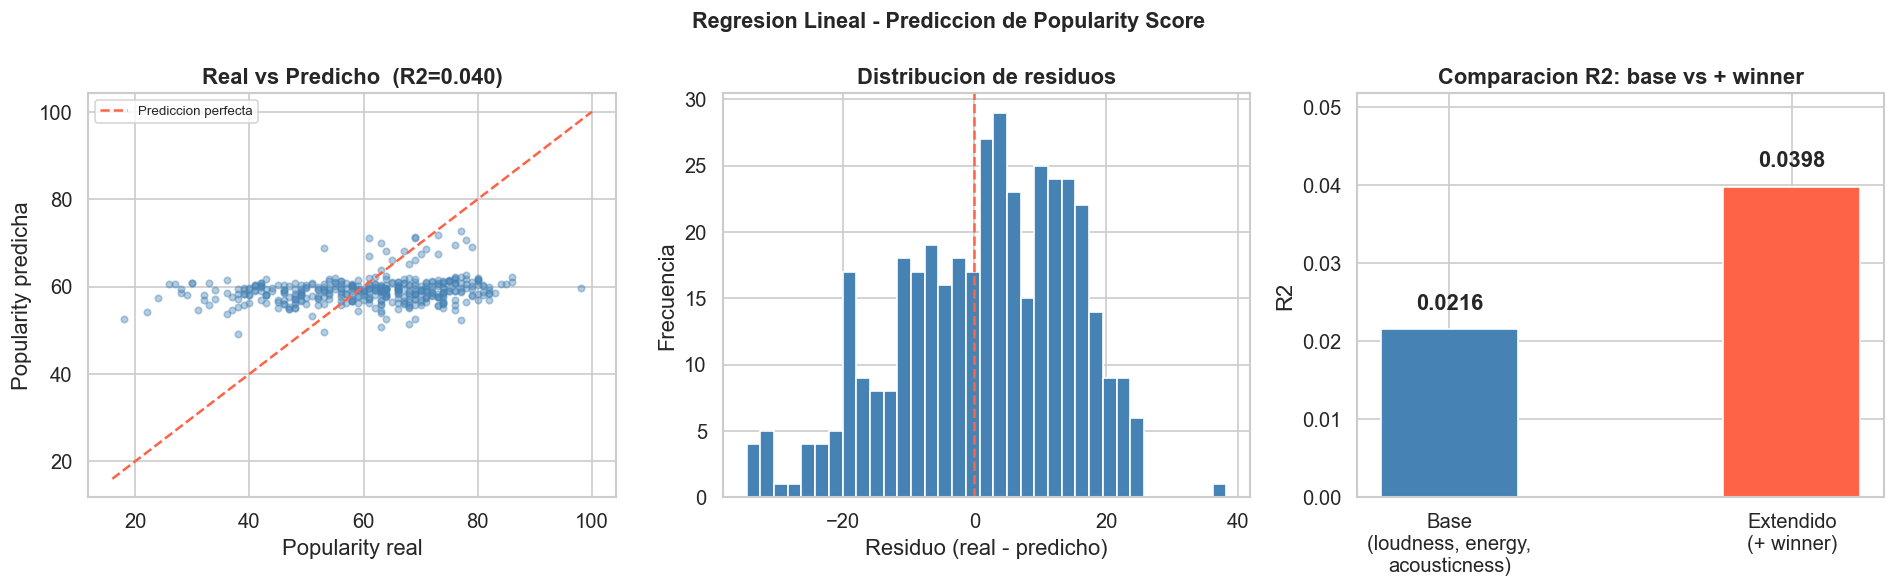

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Grafica 1: Real vs predicho (modelo seleccionado)
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15, color='steelblue')
lim = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
axes[0].plot(lim, lim, color='tomato', linewidth=1.5, linestyle='--', label='Prediccion perfecta')
axes[0].set_xlabel('Popularity real')
axes[0].set_ylabel('Popularity predicha')
axes[0].set_title(f'Real vs Predicho  (R2={r2:.3f})', fontweight='bold')
axes[0].legend(fontsize=8)

# Grafica 2: Distribucion de residuos
residuos = y_test - y_pred
axes[1].hist(residuos, bins=35, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='tomato', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residuo (real - predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de residuos', fontweight='bold')

# Grafica 3: Comparacion R2 base vs extendido
modelos_labels = ['Base\n(loudness, energy,\nacousticness)', 'Extendido\n(+ winner)']
r2_vals = [r2_base, r2_ext]
colores_bar = ['steelblue', 'tomato' if r2_ext > r2_base else 'gray']
barras = axes[2].bar(modelos_labels, r2_vals, color=colores_bar,
                     edgecolor='white', width=0.4)
axes[2].set_ylim(0, max(r2_vals) * 1.3)
axes[2].set_title('Comparacion R2: base vs + winner', fontweight='bold')
axes[2].set_ylabel('R2')
for barra, val in zip(barras, r2_vals):
    axes[2].text(barra.get_x() + barra.get_width()/2., val + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Regresion Lineal - Prediccion de Popularity Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(modelo_reg, 'modelo_regresion.pkl')
print(f'Modelo exportado: modelo_regresion.pkl')
print(f'Variables usadas: {FEATURES_FIN}')

# Ejemplo de prediccion
print()
print('Ejemplo - cancion energetica sin Grammy:')
ej1 = pd.DataFrame([{'loudness_db': -5, 'energy': 85, 'acousticness': 5, 'winner_int': 0}])
print(f'  -> popularity predicha: {modelo_ext.predict(ej1[FEATURES_EXT])[0]:.1f}')

print('Ejemplo - misma cancion con Grammy:')
ej2 = pd.DataFrame([{'loudness_db': -5, 'energy': 85, 'acousticness': 5, 'winner_int': 1}])
print(f'  -> popularity predicha: {modelo_ext.predict(ej2[FEATURES_EXT])[0]:.1f}')

---
## 3. Modelo 2 - Clustering K-Means

Los clusters se forman usando solo el perfil sonoro (`loudness_db`, `energy`, `acousticness`).
Despues analizamos cuantos ganadores Grammy caen en cada cluster.

### 3.1 Normalizacion de variables

In [11]:
# K-Means usa distancias — necesitamos que las 3 variables tengan el mismo peso
# loudness_db va de -27 a -2, mientras energy y acousticness van de 0 a 100
FEATURES_CLUSTER = ['loudness_db', 'energy', 'acousticness']

X_cluster = df[FEATURES_CLUSTER].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print('Antes de normalizar:')
print(X_cluster.describe().round(2))
print()
print('Despues (media=0, std=1):')
print(pd.DataFrame(X_scaled, columns=FEATURES_CLUSTER).describe().round(2))

Antes de normalizar:
       loudness_db   energy  acousticness
count      1994.00  1994.00       1994.00
mean         -9.01    59.68         28.86
std           3.65    22.15         29.01
min         -27.00     3.00          0.00
25%         -11.00    42.00          3.00
50%          -8.00    61.00         18.00
75%          -6.00    78.00         50.00
max          -2.00   100.00         99.00

Despues (media=0, std=1):
       loudness_db   energy  acousticness
count      1994.00  1994.00       1994.00
mean          0.00     0.00         -0.00
std           1.00     1.00          1.00
min          -4.93    -2.56         -0.99
25%          -0.55    -0.80         -0.89
50%           0.28     0.06         -0.37
75%           0.82     0.83          0.73
max           1.92     1.82          2.42


### 3.2 Metodo del codo

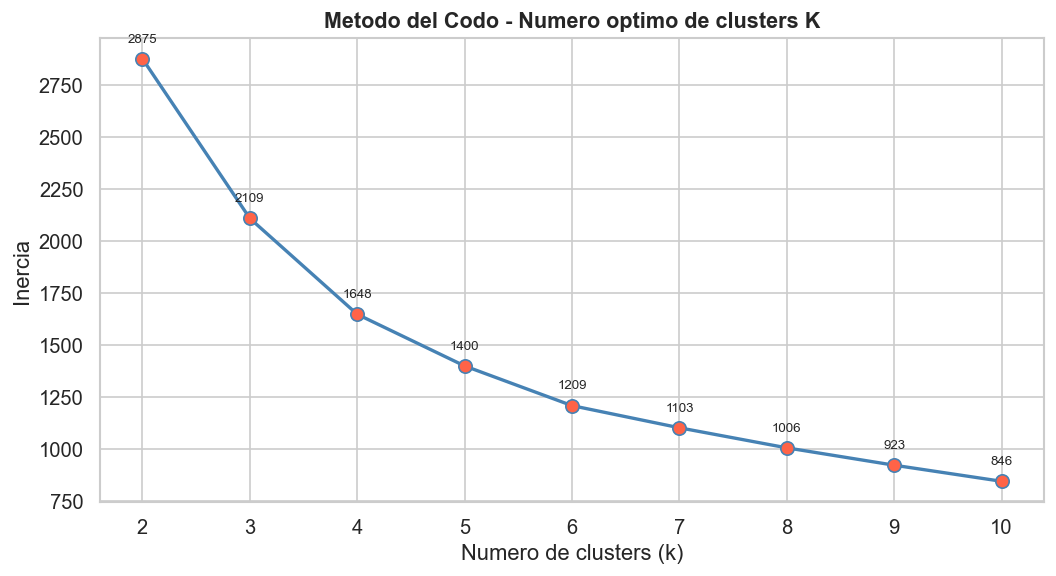

Revisa la grafica y ajusta K_OPTIMO en la siguiente celda.


In [12]:
inercias = []
rango_k  = range(2, 11)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rango_k, inercias, marker='o', color='steelblue',
        linewidth=2, markersize=8, markerfacecolor='tomato')

# Marcar cada punto con su valor de inercia
for k, inercia in zip(rango_k, inercias):
    ax.annotate(f'{inercia:.0f}', (k, inercia),
                textcoords='offset points', xytext=(0, 10), fontsize=8, ha='center')

ax.set_title('Metodo del Codo - Numero optimo de clusters K',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Numero de clusters (k)')
ax.set_ylabel('Inercia')
ax.set_xticks(list(rango_k))
plt.tight_layout()
plt.show()

print('Revisa la grafica y ajusta K_OPTIMO en la siguiente celda.')

In [13]:
# Ajusta este valor segun el codo que observes en la grafica
K_OPTIMO = 3   # <-- MODIFICAR si el codo sugiere otro valor

print(f'K optimo seleccionado: {K_OPTIMO}')

K optimo seleccionado: 3


### 3.3 Entrenamiento del modelo final

In [ ]:
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print('Canciones por cluster:')
print(df['cluster'].value_counts().sort_index())

joblib.dump(kmeans, 'modelo_kmeans.pkl')
joblib.dump(scaler, 'scaler_kmeans.pkl')
print()
print('Exportados: modelo_kmeans.pkl, scaler_kmeans.pkl')

Canciones por cluster:
cluster
0    834
1    431
2    729
Name: count, dtype: int64


### 3.4 Perfil de cada cluster

In [15]:
perfil_clusters = (
    df.groupby('cluster')[FEATURES_CLUSTER + ['popularity']]
    .mean()
    .round(2)
)

print('Perfil promedio por cluster:')
print(perfil_clusters.to_string())
print()

# Nombres automaticos basados en perfil sonoro
nombres_cluster = {}
for c in range(K_OPTIMO):
    row = perfil_clusters.loc[c]
    if row['energy'] >= 70 and row['acousticness'] <= 30:
        nombres_cluster[c] = f'Cluster {c} - Energetico'
    elif row['acousticness'] >= 50:
        nombres_cluster[c] = f'Cluster {c} - Acustico'
    else:
        nombres_cluster[c] = f'Cluster {c} - Moderado'

df['cluster_nombre'] = df['cluster'].map(nombres_cluster)

print('Resumen por cluster:')
for c in range(K_OPTIMO):
    n   = (df['cluster'] == c).sum()
    pop = df[df['cluster'] == c]['popularity'].mean()
    print(f'  {nombres_cluster[c]:<35} | {n:>4} canciones | pop media: {pop:.1f}')

Perfil promedio por cluster:
         loudness_db  energy  acousticness  popularity
cluster                                               
0              -6.11   79.87          9.42       61.15
1             -12.85   30.83         71.88       56.85
2             -10.05   53.64         25.66       59.26

Resumen por cluster:
  Cluster 0 - Energetico              |  834 canciones | pop media: 61.1
  Cluster 1 - Acustico                |  431 canciones | pop media: 56.8
  Cluster 2 - Moderado                |  729 canciones | pop media: 59.3


### 3.5 Distribucion de ganadores Grammy por cluster

In [16]:
# Analizamos cuantos ganadores Grammy caen en cada cluster
# Esto valida si el perfil sonoro energetico coincide con los artistas reconocidos

grammy_por_cluster = (
    df.groupby('cluster_nombre')['winner_int']
    .agg(
        total_canciones = 'count',
        con_grammy      = 'sum',
        pop_media       = ('popularity', 'mean') if False else 'sum'  # placeholder
    )
)

# Recalcular correctamente
grammy_por_cluster = df.groupby('cluster_nombre').agg(
    total_canciones = ('winner_int', 'count'),
    con_grammy      = ('winner_int', 'sum'),
    pop_media       = ('popularity', 'mean')
).round(2)

grammy_por_cluster['pct_grammy'] = (
    grammy_por_cluster['con_grammy'] / grammy_por_cluster['total_canciones'] * 100
).round(1)

print('Distribucion de Grammy por cluster:')
print(grammy_por_cluster.to_string())
print()

# Identificar cual cluster tiene mayor concentracion de Grammy
cluster_mas_grammy = grammy_por_cluster['pct_grammy'].idxmax()
pct_max = grammy_por_cluster.loc[cluster_mas_grammy, 'pct_grammy']
print(f'Cluster con mayor concentracion de Grammy: {cluster_mas_grammy} ({pct_max:.1f}%)')

Distribucion de Grammy por cluster:
                        total_canciones  con_grammy  pop_media  pct_grammy
cluster_nombre                                                            
Cluster 0 - Energetico              834          57      61.15         6.8
Cluster 1 - Acustico                431          24      56.85         5.6
Cluster 2 - Moderado                729          31      59.26         4.3

Cluster con mayor concentracion de Grammy: Cluster 0 - Energetico (6.8%)


ValueError: The palette dictionary is missing keys: {np.False_, np.True_}

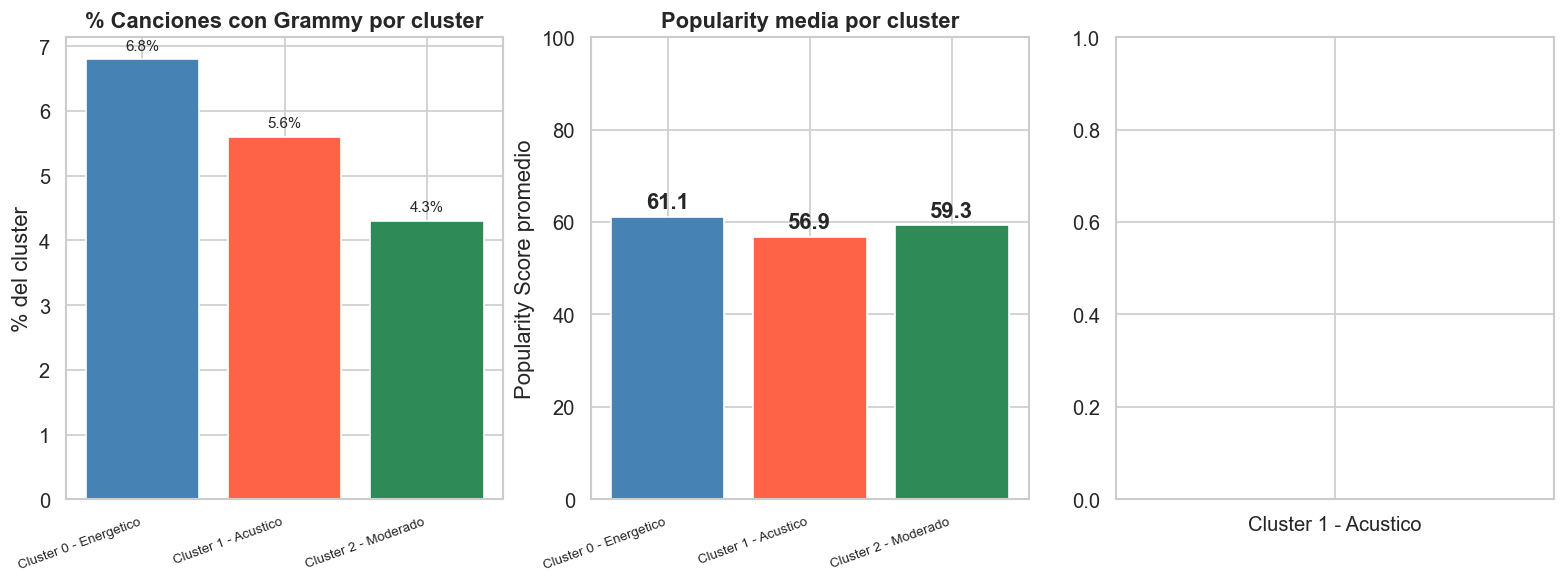

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colores = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple'][:K_OPTIMO]
cluster_nombres = grammy_por_cluster.index.tolist()

# Grafica 1: Porcentaje de Grammy por cluster
barras1 = axes[0].bar(range(len(cluster_nombres)),
                      grammy_por_cluster['pct_grammy'],
                      color=colores, edgecolor='white')
axes[0].set_xticks(range(len(cluster_nombres)))
axes[0].set_xticklabels(cluster_nombres, rotation=20, ha='right', fontsize=8)
axes[0].set_title('% Canciones con Grammy por cluster', fontweight='bold')
axes[0].set_ylabel('% del cluster')
for barra, val in zip(barras1, grammy_por_cluster['pct_grammy']):
    axes[0].text(barra.get_x() + barra.get_width()/2., val + 0.1,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# Grafica 2: Popularity media por cluster
barras2 = axes[1].bar(range(len(cluster_nombres)),
                      grammy_por_cluster['pop_media'],
                      color=colores, edgecolor='white')
axes[1].set_xticks(range(len(cluster_nombres)))
axes[1].set_xticklabels(cluster_nombres, rotation=20, ha='right', fontsize=8)
axes[1].set_title('Popularity media por cluster', fontweight='bold')
axes[1].set_ylabel('Popularity Score promedio')
axes[1].set_ylim(0, 100)
for barra, val in zip(barras2, grammy_por_cluster['pop_media']):
    axes[1].text(barra.get_x() + barra.get_width()/2., val + 1,
                 f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

# Grafica 3: Violinplot de popularity separando Grammy vs No Grammy dentro de cada cluster
sns.violinplot(
    data=df, x='cluster_nombre', y='popularity', hue='winner',
    palette={'False': 'steelblue', 'True': 'tomato'},
    split=False, ax=axes[2], legend=False
)
axes[2].set_title('Popularity: Grammy vs No Grammy\npor cluster', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=20, ha='right', fontsize=7)
handles = [plt.Rectangle((0,0),1,1, color='steelblue'), plt.Rectangle((0,0),1,1, color='tomato')]
axes[2].legend(handles, ['Sin Grammy', 'Con Grammy'], fontsize=8)

plt.suptitle('Analisis Grammy por Cluster',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Visualizacion 2D de clusters

Varianza explicada: PC1=74.7%  PC2=18.4%  Total=93.2%


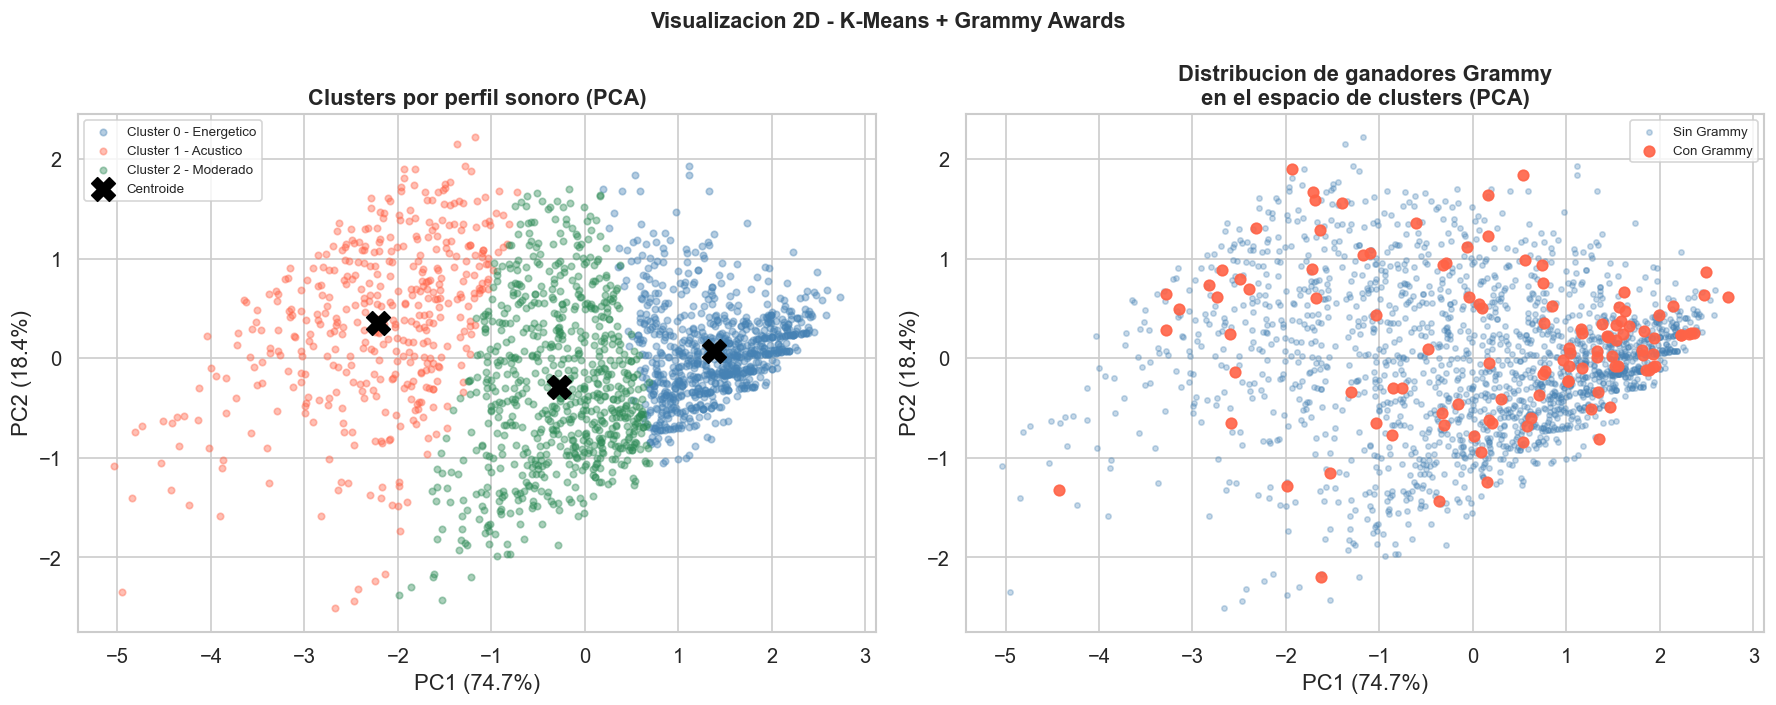

In [18]:
# PCA reduce las 3 dimensiones a 2 para visualizar los clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

varianza = pca.explained_variance_ratio_
print(f'Varianza explicada: PC1={varianza[0]*100:.1f}%  PC2={varianza[1]*100:.1f}%  Total={sum(varianza)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Grafica 1: Clusters coloreados por grupo
for c, color in zip(range(K_OPTIMO), colores):
    mask = df['cluster'] == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    alpha=0.4, s=15, color=color, label=nombres_cluster[c])

centroides_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroides_pca[:, 0], centroides_pca[:, 1],
                s=200, color='black', marker='X', zorder=5, label='Centroide')
axes[0].set_title('Clusters por perfil sonoro (PCA)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[0].legend(fontsize=8)

# Grafica 2: Mismos puntos coloreados por Grammy
mask_grammy    = df['winner_int'] == 1
mask_no_grammy = df['winner_int'] == 0
axes[1].scatter(X_pca[mask_no_grammy, 0], X_pca[mask_no_grammy, 1],
                alpha=0.3, s=10, color='steelblue', label='Sin Grammy')
axes[1].scatter(X_pca[mask_grammy, 0], X_pca[mask_grammy, 1],
                alpha=0.9, s=40, color='tomato', zorder=5, label='Con Grammy')
axes[1].set_title('Distribucion de ganadores Grammy\nen el espacio de clusters (PCA)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({varianza[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({varianza[1]*100:.1f}%)')
axes[1].legend(fontsize=8)

plt.suptitle('Visualizacion 2D - K-Means + Grammy Awards',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Conclusiones y criterios para el servicio premium

In [19]:
pop_por_c       = df.groupby('cluster')['popularity'].mean()
cluster_premium = pop_por_c.idxmax()
n_premium       = (df['cluster'] == cluster_premium).sum()
pop_premium     = pop_por_c[cluster_premium]
pct_grammy_prem = grammy_por_cluster.loc[nombres_cluster[cluster_premium], 'pct_grammy']

print('=' * 60)
print('  RESUMEN - Modelos ML')
print('=' * 60)

print('MODELO 1 - Regresion Lineal')
print(f'  Modelo base  (3 vars):      R2={r2_base:.4f}  RMSE={rmse_base:.2f}')
print(f'  Modelo ext   (+ winner):    R2={r2_ext:.4f}  RMSE={rmse_ext:.2f}')
print(f'  Mejora por winner:          delta R2={delta_r2:+.4f}')
if abs(delta_r2) < 0.005:
    print('  -> winner no agrega poder predictivo significativo al modelo.')
    print('     El perfil sonoro es el predictor principal de popularity.')
else:
    print(f'  -> winner mejora el modelo en {delta_r2:.4f} puntos de R2.')
print()

print('MODELO 2 - K-Means Clustering')
print(f'  Clusters generados: {K_OPTIMO}')
for c in range(K_OPTIMO):
    n   = (df['cluster'] == c).sum()
    pop = df[df['cluster'] == c]['popularity'].mean()
    pct_g = grammy_por_cluster.loc[nombres_cluster[c], 'pct_grammy']
    print(f'  {nombres_cluster[c]:<35} | {n:>4} canciones | pop: {pop:.1f} | Grammy: {pct_g:.1f}%')
print()

print('CRITERIOS RECOMENDADOS PARA EL SERVICIO PREMIUM')
print(f'  Cluster base:          {nombres_cluster[cluster_premium]}')
print(f'  Canciones candidatas:  {n_premium:,} ({n_premium/len(df)*100:.1f}% del catalogo)')
print(f'  Popularity media:      {pop_premium:.1f} pts')
print(f'  Concentracion Grammy:  {pct_grammy_prem:.1f}%')
print()
print('  Perfil sonoro del cluster premium:')
for feat in FEATURES_CLUSTER:
    print(f'    {feat:<15}: {perfil_clusters.loc[cluster_premium, feat]:.1f}')
print('=' * 60)
print('  Archivos: modelo_regresion.pkl | modelo_kmeans.pkl | scaler_kmeans.pkl')
print('=' * 60)

  RESUMEN - Modelos ML
MODELO 1 - Regresion Lineal
  Modelo base  (3 vars):      R2=0.0216  RMSE=13.54
  Modelo ext   (+ winner):    R2=0.0398  RMSE=13.42
  Mejora por winner:          delta R2=+0.0182
  -> winner mejora el modelo en 0.0182 puntos de R2.

MODELO 2 - K-Means Clustering
  Clusters generados: 3
  Cluster 0 - Energetico              |  834 canciones | pop: 61.1 | Grammy: 6.8%
  Cluster 1 - Acustico                |  431 canciones | pop: 56.8 | Grammy: 5.6%
  Cluster 2 - Moderado                |  729 canciones | pop: 59.3 | Grammy: 4.3%

CRITERIOS RECOMENDADOS PARA EL SERVICIO PREMIUM
  Cluster base:          Cluster 0 - Energetico
  Canciones candidatas:  834 (41.8% del catalogo)
  Popularity media:      61.1 pts
  Concentracion Grammy:  6.8%

  Perfil sonoro del cluster premium:
    loudness_db    : -6.1
    energy         : 79.9
    acousticness   : 9.4
  Archivos: modelo_regresion.pkl | modelo_kmeans.pkl | scaler_kmeans.pkl


In [ ]:
df.to_csv('spotify_modelos_final.csv', index=False)
print('Dataset exportado: spotify_modelos_final.csv')
print(f'Columnas nuevas: cluster, cluster_nombre')